Gamma_phi (1/us) | Tphi (us) | T2_intrinsic theory (us) | T2_echo fit (us) | T2* fit (us)
       2000.0000 |    500.00 |                 142.86 |           142.86 | 19.08
       2583.0993 |    387.13 |                 131.87 |           131.87 | 20.50
       3336.2011 |    299.74 |                 119.96 |           119.96 | 18.80
       4308.8694 |    232.08 |                 107.42 |           107.42 | 18.57
       5565.1188 |    179.69 |                  94.65 |            94.65 | 19.11
       7187.6273 |    139.13 |                  82.05 |            82.05 | 18.51
       9283.1777 |    107.72 |                  70.01 |            70.01 | 17.56
      11989.6850 |     83.41 |                  58.86 |            58.86 | 16.30
      15485.2737 |     64.58 |                  48.82 |            48.82 | 16.41
      20000.0000 |     50.00 |                  40.00 |            40.00 | 15.25

Saved plot to step6_parameter_sweep.png


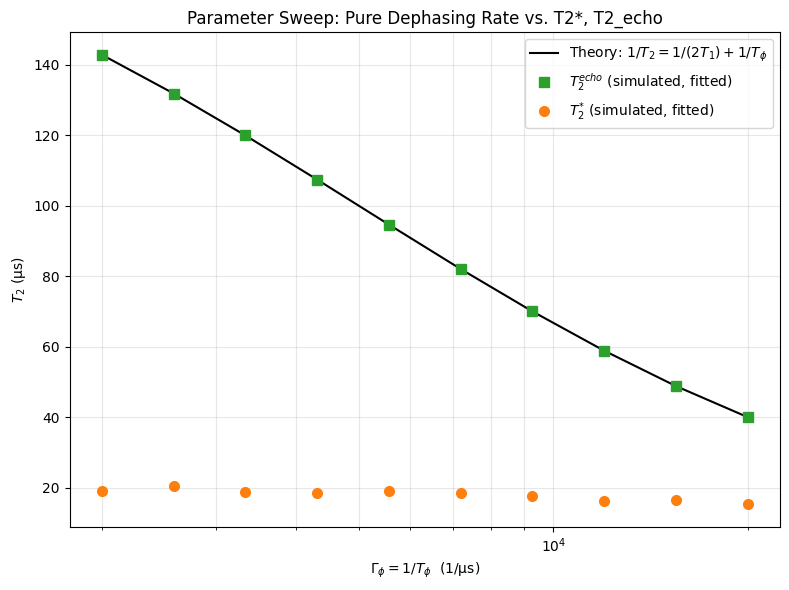

In [15]:
"""
QARC 2026 Hackathon - Step 6: Parameter Sweep over Pure Dephasing Rate
--------------------------------------------------------------------------
Vary the pure dephasing rate Gamma_phi = 1/Tphi over one order of magnitude
(holding T1 fixed), and see how T2* and T2_echo respond. This directly
probes 1/T2 = 1/(2T1) + 1/Tphi.

Since T2_echo (in our model) is limited ONLY by the intrinsic Markovian
channels (T1, Tphi) -- the quasi-static noise is refocused away -- we expect
T2_echo to closely follow the textbook curve  1/T2 = 1/(2T1) + 1/Tphi.
T2* additionally includes the fixed quasi-static contribution and should
sit below the T2_echo curve at every point, saturating once Tphi-limited
decay becomes sub-dominant to the quasi-static contribution.

Author: Saksham
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# 1. Fixed parameters
# ----------------------------------------------------------------------
T1 = 100e-6
delta0 = 2 * np.pi * 1e6
T_inhom = 25e-6
sigma_static = np.sqrt(2) / T_inhom

# Sweep Gamma_phi = 1/Tphi over one order of magnitude
Gamma_phi_list = np.logspace(np.log10(1 / 500e-6), np.log10(1 / 50e-6), 10)  # 1/us range
Tphi_list = 1 / Gamma_phi_list

def free_evolve(rx0, ry0, rz0, t, delta, T1, T2, rz_eq=1.0):
    decay_xy = np.exp(-t / T2)
    rx = decay_xy * (rx0 * np.cos(delta * t) + ry0 * np.sin(delta * t))
    ry = decay_xy * (-rx0 * np.sin(delta * t) + ry0 * np.cos(delta * t))
    rz = rz_eq + (rz0 - rz_eq) * np.exp(-t / T1)
    return rx, ry, rz

def apply_rx(rx, ry, rz, theta):
    c, s = np.cos(theta), np.sin(theta)
    ry_new = ry * c - rz * s
    rz_new = ry * s + rz * c
    return rx, ry_new, rz_new

rng = np.random.default_rng(999)
n_shots = 600
n_points = 45

T2star_results = []
T2star_err = []
T2echo_results = []
T2echo_err = []
T2_intrinsic_theory = []

for Tphi in Tphi_list:
    T2_intrinsic = 1 / (1 / (2 * T1) + 1 / Tphi)
    T2_intrinsic_theory.append(T2_intrinsic)

    # Ramsey signal is dominated by whichever is SHORTER: T2_intrinsic or the
    # fixed quasi-static T_inhom -- size its time window around the shorter
    # (faster-decaying) of the two so the fit always sees the full decay.
    T2star_rough_scale = 1 / (1 / T2_intrinsic + 1 / T_inhom)
    tau_list_ramsey = np.linspace(0, 6 * T2star_rough_scale, n_points)
    # Echo is limited only by T2_intrinsic (quasi-static part refocused away)
    tau_list_echo = np.linspace(0, 4 * T2_intrinsic, n_points)

    delta_static_samples = rng.normal(0, sigma_static, size=n_shots)

    # ---- Ramsey ensemble ----
    z_ramsey = np.zeros(n_points)
    for ds in delta_static_samples:
        delta_shot = delta0 + ds
        rx1, ry1, rz1 = free_evolve(0.0, -1.0, 0.0, tau_list_ramsey, delta_shot, T1, T2_intrinsic)
        _, _, rz_meas = apply_rx(rx1, ry1, rz1, np.pi / 2)
        z_ramsey += rz_meas
    z_ramsey /= n_shots

    # ---- Echo ensemble ----
    z_echo = np.zeros(n_points)
    for ds in delta_static_samples:
        delta_shot = delta0 + ds
        rx1, ry1, rz1 = free_evolve(0.0, -1.0, 0.0, tau_list_echo / 2, delta_shot, T1, T2_intrinsic)
        rx2, ry2, rz2 = apply_rx(rx1, ry1, rz1, np.pi)
        rx3, ry3, rz3 = free_evolve(rx2, ry2, rz2, tau_list_echo / 2, delta_shot, T1, T2_intrinsic)
        _, _, rz_meas = apply_rx(rx3, ry3, rz3, np.pi / 2)
        z_echo += rz_meas
    z_echo /= n_shots

    # ---- Fits ----
    def ramsey_model(tau, A, T2star, delta_fit, phi0, B):
        return A * np.exp(-tau / T2star) * np.cos(delta_fit * tau + phi0) + B
    try:
        popt, pcov = curve_fit(
            ramsey_model, tau_list_ramsey, z_ramsey,
            p0=[-1.0, T2star_rough_scale, delta0, 0.0, 0.0], maxfev=20000,
            bounds=([-1.2, 1e-7, delta0 * 0.5, -np.pi, -0.2],
                     [1.2, 1e-3, delta0 * 1.5, np.pi, 0.2]))
        T2star_results.append(popt[1])
        T2star_err.append(np.sqrt(np.diag(pcov))[1])
    except RuntimeError:
        T2star_results.append(np.nan)
        T2star_err.append(np.nan)

    def echo_model(tau, A, T2echo, B):
        return A * np.exp(-tau / T2echo) + B
    try:
        popt2, pcov2 = curve_fit(
            echo_model, tau_list_echo, z_echo,
            p0=[-1.0, T2_intrinsic, 0.0], maxfev=20000,
            bounds=([-1.2, 1e-7, -0.2], [1.2, 1e-3, 0.2]))
        T2echo_results.append(popt2[1])
        T2echo_err.append(np.sqrt(np.diag(pcov2))[1])
    except RuntimeError:
        T2echo_results.append(np.nan)
        T2echo_err.append(np.nan)

T2star_results = np.array(T2star_results)
T2echo_results = np.array(T2echo_results)
T2_intrinsic_theory = np.array(T2_intrinsic_theory)

print("Gamma_phi (1/us) | Tphi (us) | T2_intrinsic theory (us) | T2_echo fit (us) | T2* fit (us)")
for g, tphi, t2i, t2e, t2s in zip(Gamma_phi_list, Tphi_list, T2_intrinsic_theory,
                                    T2echo_results, T2star_results):
    print(f"{g:16.4f} | {tphi*1e6:9.2f} | {t2i*1e6:22.2f} | {t2e*1e6:16.2f} | {t2s*1e6:.2f}")

# ----------------------------------------------------------------------
# 2. Plot
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Gamma_phi_list * 1e-6 * 1e6, T2_intrinsic_theory * 1e6, '-', color='black',
        label=r"Theory: $1/T_2 = 1/(2T_1) + 1/T_\phi$")
ax.plot(Gamma_phi_list * 1e-6 * 1e6, T2echo_results * 1e6, 's', color='tab:green', ms=7,
        label=r"$T_2^{echo}$ (simulated, fitted)")
ax.plot(Gamma_phi_list * 1e-6 * 1e6, T2star_results * 1e6, 'o', color='tab:orange', ms=7,
        label=r"$T_2^{*}$ (simulated, fitted)")
ax.set_xscale('log')
ax.set_xlabel(r"$\Gamma_\phi = 1/T_\phi$  (1/µs)")
ax.set_ylabel(r"$T_2$ (µs)")
ax.set_title("Parameter Sweep: Pure Dephasing Rate vs. T2*, T2_echo")
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("parameter_sweep.png", dpi=150)
print("\nSaved plot to step6_parameter_sweep.png")
